# 📦 Brazilian E-Commerce 데이터를 통한 라스트마일 & 고객 만족도 분석

> **데이터**: Kaggle · Brazilian E-Commerce Public Dataset by Olist  
> **핵심 질문**: 라스트마일 배송 지연이 고객 NPS(추천 의향)에 얼마나 영향을 주는가?  
> **AARRR 선정**: **Referral(추천/NPS)**

---

## 📋 목차

```
STEP 0.  환경 설정 — 라이브러리 임포트 & 스타일
STEP 1.  데이터 로딩 — 8개 테이블 불러오기
STEP 2.  데이터 이해 — ERD 구조 파악, 기초 확인
STEP 3.  테이블 조인 — 마스터 테이블 만들기
STEP 4.  전처리 — 날짜 변환, 파생변수 생성
STEP 5.  EDA — 분포, 추이, 라스트마일 시각화
STEP 6.  AARRR 선정 근거 — 왜 Referral인가
STEP 7.  라스트마일 배송 분석 — 지연 패턴, 지역/카테고리
STEP 8.  고객 만족도 & NPS 분석
STEP 9.  Referral 심화 — 라스트마일 × NPS 상관관계
STEP 10. 코호트 분석 — 월별 NPS & 라스트마일 추이
STEP 11. 물류 공백 클러스터링 — 물류센터 위치 제안
STEP 12. 인사이트 & 액션 플랜
```

---
## STEP 0 환경 설정

분석에 필요한 라이브러리 import를 불러옵니다.

In [47]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

In [69]:
import matplotlib.font_manager as fm

# Mac 기본 한글 폰트
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [67]:
# ── pandas 출력 옵션 ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 30)          # 컬럼이 많아도 가로로 다 보여주기
pd.set_option('display.float_format', '{:.2f}'.format)  # 소수점 2자리 고정

# ── 차트 공통 스타일 ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize'   : (13, 5),
    'figure.dpi'       : 110,
    'axes.spines.top'  : False,    # 위쪽 테두리 제거 → 더 깔끔하게
    'axes.spines.right': False,
    'font.size'        : 11,
})

# 자주 쓸 색상
C_BLUE = '#378ADD'
C_OK   = '#1D9E75'   # 온타임 → 초록
C_LATE = '#E24B4A'   # 지연   → 빨강

---
## STEP 1 - 데이터 로딩

pd.read_csv()`로 8개 CSV 파일을 불러옵니다.  
파일명이 길어서 딕셔너리로 한 번에 처리합니다.

In [48]:
DATA_DIR = "Data"

dfs = {
    'orders': orders, 'customers': customers, 'items': items,
    'reviews': reviews, 'products': products, 'sellers': sellers, 'payments': payments
}
orders    = pd.read_csv(os.path.join(DATA_DIR, "olist_orders_dataset.csv"))
customers = pd.read_csv(os.path.join(DATA_DIR, "olist_customers_dataset.csv"))
items     = pd.read_csv(os.path.join(DATA_DIR, "olist_order_items_dataset.csv"))
reviews   = pd.read_csv(os.path.join(DATA_DIR, "olist_order_reviews_dataset.csv"))
products  = pd.read_csv(os.path.join(DATA_DIR, "olist_products_dataset.csv"))
sellers   = pd.read_csv(os.path.join(DATA_DIR, "olist_sellers_dataset.csv"))
payments  = pd.read_csv(os.path.join(DATA_DIR, "olist_order_payments_dataset.csv"))
geo       = pd.read_csv(os.path.join(DATA_DIR, "olist_geolocation_dataset.csv"))
cat_name   = pd.read_csv(os.path.join(DATA_DIR, "product_category_name_translation.csv"))

print("완료!")

완료!


## STEP 2 - 데이터 이해

분석하기 전에 각 테이블이 어떤 정보를 담고 있는지 먼저 파악합니다.

### 테이블 관계도 (ERD)
```
[customers] ──customer_id──▶ [orders] ──order_id──▶ [order_items] ──product_id──▶ [products]
                                │                          │
                                │                    seller_id ──▶ [sellers]
                                ├──order_id──▶ [order_payments]
                                └──order_id──▶ [order_reviews]
```

**핵심 테이블**: `orders` — 모든 분석의 중심축

| 컬럼 | 의미 |
|------|------|
| `order_purchase_timestamp` | 고객이 주문한 시각 |
| `order_delivered_customer_date` | 고객이 실제 수령한 날짜 |
| `order_estimated_delivery_date` | 시스템이 약속한 배송 완료일 |
| `order_status` | 주문 상태 (delivered / shipped / canceled 등) |


In [49]:
# ── orders 테이블 --
print('=== orders 컬럼 목록 ===')
print(orders.dtypes)   # 각 컬럼의 데이터 타입 확인
print()
orders.head()          # 상위 5행 미리보기

=== orders 컬럼 목록 ===
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object



,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [50]:
# ── 결측치 현황 확인 ─────────────────────────────────────────────────────────
# isnull().sum() : 컬럼별 결측치(NaN) 개수
print('=== 결측치가 있는 컬럼만 표시 ===')
for name, df in dfs.items():
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if len(miss) > 0:
        print(f'\n[{name}]')
        for col, cnt in miss.items():
            print(f'  {col}: {cnt:,}개 ({cnt/len(df)*100:.1f}%)')
    else:
        print(f'[{name}] 결측치 없음')

=== 결측치가 있는 컬럼만 표시 ===

[orders]
  order_approved_at: 160개 (0.2%)
  order_delivered_carrier_date: 1,783개 (1.8%)
  order_delivered_customer_date: 2,965개 (3.0%)
[customers] 결측치 없음
[items] 결측치 없음

[reviews]
  review_comment_title: 87,656개 (88.3%)
  review_comment_message: 58,247개 (58.7%)

[products]
  product_category_name: 610개 (1.9%)
  product_name_lenght: 610개 (1.9%)
  product_description_lenght: 610개 (1.9%)
  product_photos_qty: 610개 (1.9%)
  product_weight_g: 2개 (0.0%)
  product_length_cm: 2개 (0.0%)
  product_height_cm: 2개 (0.0%)
  product_width_cm: 2개 (0.0%)
[sellers] 결측치 없음
[payments] 결측치 없음


---
## STEP 3 · 테이블 조인 — 마스터 테이블 만들기

여러 테이블을 `order_id` 또는 `customer_id` 기준으로 합쳐서
분석에 필요한 정보가 **한 행에 모두 담긴** 마스터 테이블을 만듭니다.

> 💡 `merge()` = SQL의 JOIN과 같습니다  
> `how='left'` = 왼쪽 테이블 기준으로 합치기 (없는 값은 NaN)

In [51]:
# ── STEP 3-1: 배송 완료 주문만 필터링 ───────────────────────────────────────
# 배송이 완료돼야 '실제 배송일'이 존재합니다
# 취소/배송 중인 주문은 지연 분석 대상이 아닙니다
delivered = orders[orders['order_status'] == 'delivered'].copy()

print(f'전체 주문: {len(orders):,}건')
print(f'배송 완료: {len(delivered):,}건 ({len(delivered)/len(orders)*100:.1f}%)')
print(f'제외됨:   {len(orders)-len(delivered):,}건 (취소/배송중 등)')

전체 주문: 99,441건
배송 완료: 96,478건 (97.0%)
제외됨:   2,963건 (취소/배송중 등)


In [52]:
# ── STEP 3-2: 리뷰 테이블 조인 ──────────────────────────────────────────────
# 같은 주문에 리뷰가 여러 개인 경우 → 점수 평균 사용
review_agg = (
    reviews
    .groupby('order_id')['review_score']
    .mean()
    .reset_index()
)

master = delivered.merge(review_agg, on='order_id', how='left')
print(f'리뷰 조인 후: {len(master):,}행  리뷰 있는 주문: {master["review_score"].notna().sum():,}건')

리뷰 조인 후: 96,478행  리뷰 있는 주문: 95,832건


In [53]:
# ── STEP 3-3: 고객 정보 조인 ────────────────────────────────────────────────
# customer_id       : 주문마다 새로 발급 (같은 사람도 다를 수 있음)
# customer_city         : 고객이 등록한 도시 (배송지 아님) -> 도시별 배송 지연 분석에서 사용
# customer_unique_id: 실제 사람을 구분하는 식별자 → 코호트 분석에서 사용
master = master.merge(
    customers[['customer_id', 'customer_unique_id','customer_city','customer_state']],
    on='customer_id',
    how='left'
)

In [54]:
# ── STEP 3-4: 주문 금액 집계 후 조인 ────────────────────────────────────────
# items 테이블: 주문 1건에 상품이 여러 개일 수 있어서 order_id로 묶어서 합산
# shipping_limit_date: 판매자 발송 기한 (min = 가장 빠른 기한 기준)
order_value = (
    items
    .groupby('order_id')
    .agg(
        order_value   = ('price', 'sum'),           # 상품 가격 합계
        freight_value = ('freight_value', 'sum'),   # 배송비 합계
        item_count    = ('order_item_id', 'count'), # 상품 개수
        shipping_limit_date = ('shipping_limit_date', 'min')  # 가장 빠른 발송 기한
    )
    .reset_index()
)
master = master.merge(order_value, on='order_id', how='left')

In [55]:
# ── STEP 3-5: 결제 정보 조인 ────────────────────────────────────────────────
# 한 주문에 결제 방법이 여러 개일 수 있어서 대표값(첫 번째 행)만 사용
pay_main = payments.drop_duplicates('order_id')[['order_id', 'payment_type', 'payment_installments']]
master = master.merge(pay_main, on='order_id', how='left')


In [56]:
# ── STEP 3-6: 상품 카테고리 조인 ────────────────────────────────────────────
#  신규 추가: items → products → cat_name 순서로 연결
# 주문에 상품이 여러 개면 첫 번째 상품의 카테고리를 대표값으로 사용
item_category = (
    items[['order_id', 'product_id']]
    .drop_duplicates('order_id')                        # 주문당 1행
    .merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
    .merge(cat_name, on='product_category_name', how='left')  # 영문 카테고리명
    [['order_id', 'product_category_name', 'product_category_name_english']]  # product_category_name_english = 영문명
    .rename(columns={'product_category_name_english': 'category_en'})
)
master = master.merge(item_category, on='order_id', how='left')

print(f'\n✅ 마스터 테이블 완성: {len(master):,}행 × {master.shape[1]}컬럼')
print('컬럼 목록:')
print(master.columns.tolist())


✅ 마스터 테이블 완성: 96,478행 × 20컬럼
컬럼 목록:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'review_score', 'customer_unique_id', 'customer_city', 'customer_state', 'order_value', 'freight_value', 'item_count', 'shipping_limit_date', 'payment_type', 'payment_installments', 'product_category_name', 'category_en']


In [95]:
seller_state = items[['order_id', 'seller_id']].drop_duplicates('order_id').merge(
    sellers[['seller_id', 'seller_state']], on='seller_id', how='left'
)
master = master.merge(seller_state, on='order_id', how='left')

---
## STEP 4 - 전처리 (날짜 변환 & 파생변수 생성)


| 파생변수 | 계산 방법 | 의미 |
|----------|-----------|------|
| `delivery_delay_days` | delivered - estimated | 지연 일수 |
| `is_delayed` | delay_days > 0 | 지연 여부 (True/False) |
| `delay_bucket` |  | 지연구간 |
| `actual_delivery_days` | delivered - purchase | 실제 배송 소요일 |
| `seller_late` | carrier_date > shipping_limit_date | 판매자 발송 지연 여부 |
| `purchase_month` | 주문일의 연월 | 코호트 분석용 |
| `is_repurchase` | customer_unique_id 주문 횟수 > 1 | 재구매 여부 |


In [57]:
# ── 날짜 컬럼을 문자열 → datetime 타입으로 변환 ──────────────────────────────
# errors='coerce': 변환 실패 시 에러 대신 NaT(= 날짜 없음)으로 처리
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
]
for col in date_cols:
    master[col] = pd.to_datetime(master[col], errors='coerce')

print('날짜 타입 변환 완료:')
print(master[date_cols].dtypes)

날짜 타입 변환 완료:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
shipping_limit_date              datetime64[ns]
dtype: object


In [61]:
# ── 파생변수 생성 ────────────────────────────────────────────────────────────

# 실제 배송 소요일: 날짜 차이를 구하면 timedelta가 나옴 → .dt.days로 '일' 단위 정수 추출
master['delivery_days_actual'] = (
    master['order_delivered_customer_date'] - master['order_purchase_timestamp']
).dt.days

# 예상 배송 소요일
master['delivery_days_estimated'] = (
    master['order_estimated_delivery_date'] - master['order_purchase_timestamp']
).dt.days

# 지연일: 양수면 늦게 도착, 음수면 일찍 도착
master['delivery_delay_days'] = (
    master['delivery_days_actual'] - master['delivery_days_estimated']
)

# 지연 여부 (True/False)
master['is_late'] = master['delivery_delay_days'] > 0

# 지연 여부 — 판매자가 기한 내에 택배사에 넘겼는지 확인
master['is_seller_late'] = (
    master['order_delivered_carrier_date'] > master['shipping_limit_date']
)


# 구매 연월 (코호트 분석에서 사용)
master['purchase_month'] = master['order_purchase_timestamp'].dt.to_period('M')

# 재구매 여부
master['is_repeat_customer'] = master.duplicated('customer_unique_id', keep=False)

# 이상치 제거: 배송일이 음수거나 비정상적으로 큰 행 제거
master = master[
    (master['delivery_days_actual'] > 0) &
    (master['delivery_days_actual'] < 120)
].copy()

print('✅ 파생변수 생성 완료')
master[['delivery_days_actual', 'delivery_days_estimated',
         'delivery_delay_days', 'is_late']].describe()

✅ 파생변수 생성 완료


,delivery_days_actual,delivery_days_estimated,delivery_delay_days
count,96414.000000,96414.000000,96414.000000
mean,12.028367,23.371035,-11.342668
std,8.996976,8.757191,9.716145
min,1.000000,2.000000,-146.000000
25%,6.000000,18.000000,-16.000000
50%,10.000000,23.000000,-12.000000
75%,15.000000,28.000000,-7.000000
max,118.000000,155.000000,105.000000


In [60]:
# ── 지연 구간 컬럼 추가 ──────────────────────────────────────────────────────
# pd.cut(): 연속 숫자를 구간 레이블로 변환
master['delay_bucket'] = pd.cut(
    master['delivery_delay_days'],
    bins=[-999, -10, -5, 0, 3, 7, 14, 999],
    labels=['10일+ 일찍', '5-10일 일찍', '5일 내 일찍', '정시', '1-3일 지연', '4-7일 지연', '7일+ 지연']
)

print('지연 구간별 주문 수:')
print(master['delay_bucket'].value_counts().sort_index())

지연 구간별 주문 수:
delay_bucket
10일+ 일찍     59080
5-10일 일찍    21663
5일 내 일찍      8407
정시           2354
1-3일 지연      1795
4-7일 지연      1667
7일+ 지연       1448
Name: count, dtype: int64


In [63]:
# 라스트마일 소요일 (택배사 인수 → 고객 수령)
master['last_mile_days'] = (
    master['order_delivered_customer_date'] - master['order_delivered_carrier_date']
).dt.days

# 라스트마일 구간
master['last_mile_bucket'] = pd.cut(
    master['last_mile_days'],
    bins=[0, 3, 7, 14, 999],
    labels=['3일 이내', '4-7일', '8-14일', '14일+']
)

# 라스트마일 소요일이 음수거나 60일 이상인 이상치 제거
master = master[
    (master['last_mile_days'] > 0) &
    (master['last_mile_days'] < 60)
].copy()

print('라스트마일 구간별 주문 수:')
print(master['last_mile_bucket'].value_counts().sort_index())

라스트마일 구간별 주문 수:
last_mile_bucket
3일 이내    20223
4-7일     32014
8-14일    26470
14일+     14830
Name: count, dtype: int64


---
## STEP 5 - EDA — 탐색적 데이터 분석

데이터의 전체적인 분포와 패턴을 파악합니다.  
"데이터가 어떻게 생겼는지" 눈으로 먼저 확인하는 단계입니다.


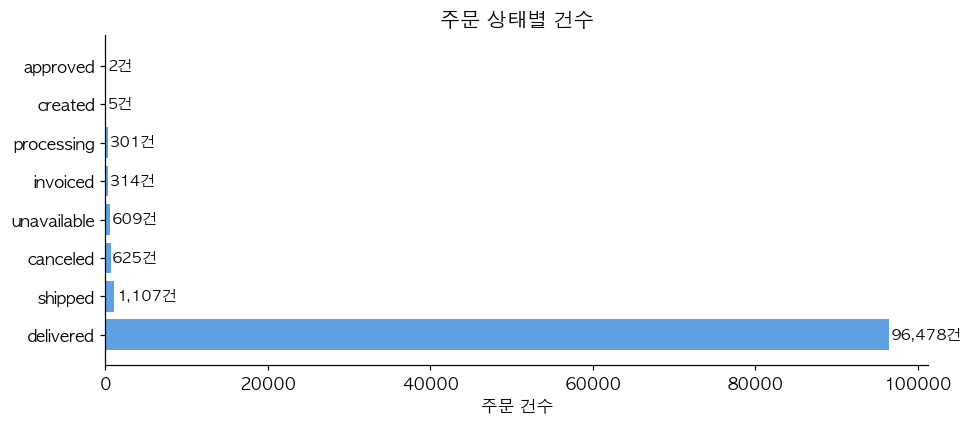

In [70]:
# ── 5-1: 주문 상태 분포 ──────────────────────────────────────────────────────
status_counts = orders['order_status'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(status_counts.index, status_counts.values, color=C_BLUE, alpha=0.8)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 200, bar.get_y() + bar.get_height()/2,
            f'{w:,.0f}건', va='center', fontsize=10)
ax.set_title('주문 상태별 건수', fontweight='bold')
ax.set_xlabel('주문 건수')
plt.tight_layout()
plt.show()


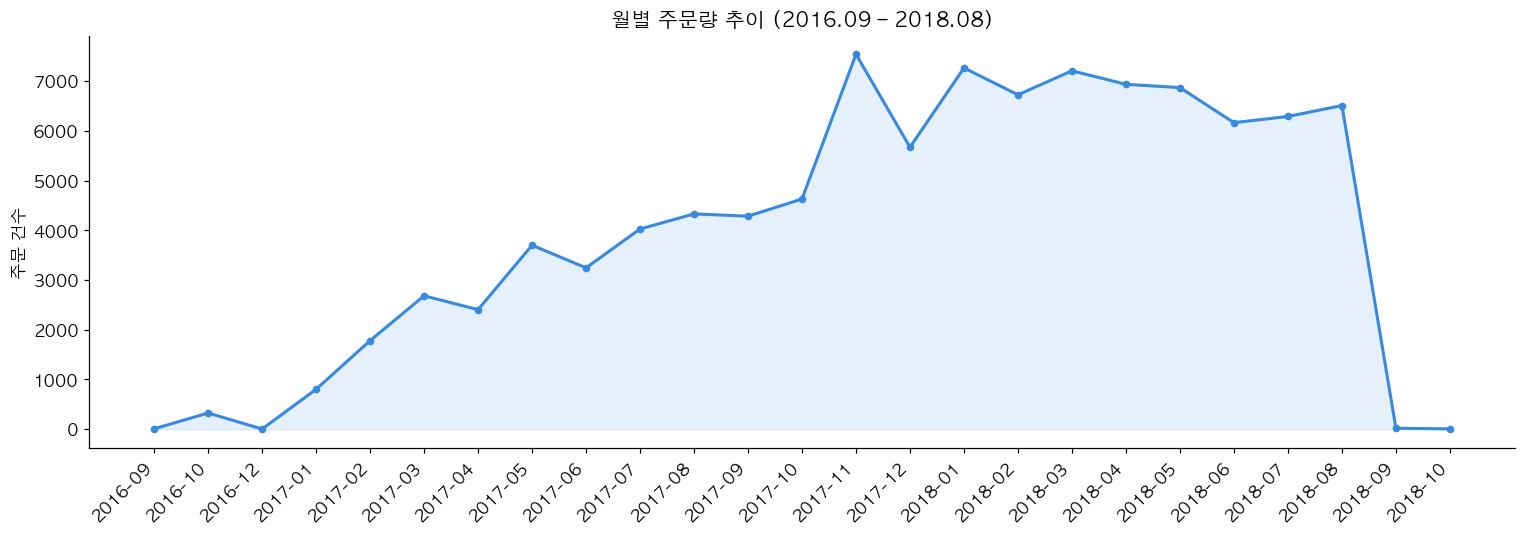

분석 기간: 2016-09 ~ 2018-10
월 최고 주문량: 7,544건 (2017-11)


In [72]:
# ── 5-2: 월별 주문량 추이 ────────────────────────────────────────────────────
orders['purchase_month'] = pd.to_datetime(
    orders['order_purchase_timestamp'], errors='coerce'
).dt.to_period('M')

monthly = orders.groupby('purchase_month').size().reset_index(name='count')
monthly['purchase_month'] = monthly['purchase_month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['purchase_month'], monthly['count'],
        marker='o', markersize=4, color=C_BLUE, linewidth=2)
ax.fill_between(monthly['purchase_month'], monthly['count'], alpha=0.12, color=C_BLUE)
plt.xticks(rotation=45, ha='right')
ax.set_title('월별 주문량 추이 (2016.09 – 2018.08)', fontweight='bold')
ax.set_ylabel('주문 건수')
plt.tight_layout()
plt.show()

print(f'분석 기간: {monthly["purchase_month"].min()} ~ {monthly["purchase_month"].max()}')
print(f'월 최고 주문량: {monthly["count"].max():,}건 ({monthly.loc[monthly["count"].idxmax(), "purchase_month"]})')


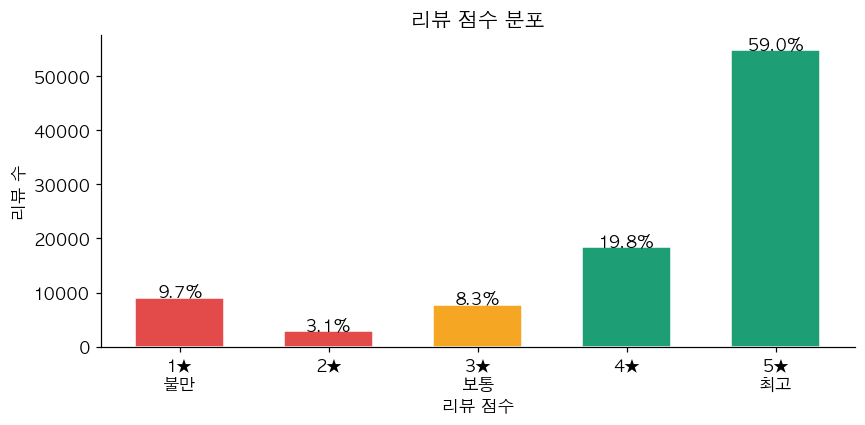

In [79]:
# ── 5-3: 리뷰 점수 분포 ──────────────────────────────────────────────────────
# review_score를 정수로 변환 후 집계
score_counts = master['review_score'].dropna().astype(int).value_counts().sort_index()
score_pct    = (score_counts / score_counts.sum() * 100).round(1)

bar_colors = [C_LATE, C_LATE, '#F5A623', C_OK, C_OK]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(score_counts.index, score_counts.values,
              color=bar_colors, width=0.6, edgecolor='white')
for bar, pct in zip(bars, score_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{pct}%', ha='center', fontsize=11, fontweight='bold')

ax.set_title('리뷰 점수 분포', fontweight='bold')
ax.set_xlabel('리뷰 점수')
ax.set_ylabel('리뷰 수')
ax.set_xticks([1,2,3,4,5])
ax.set_xticklabels(['1★\n불만', '2★', '3★\n보통', '4★', '5★\n최고'])
plt.tight_layout()
plt.show()

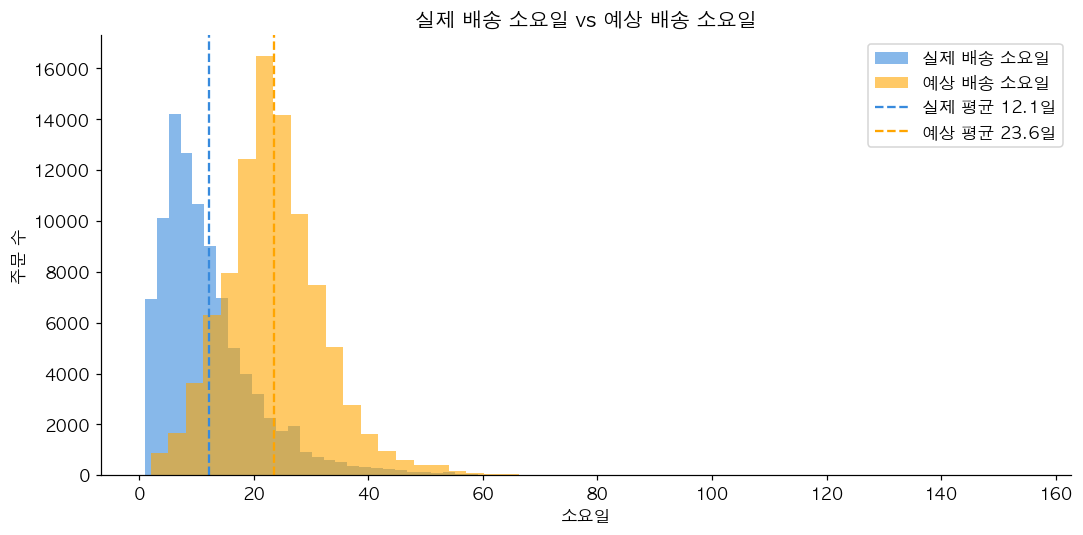

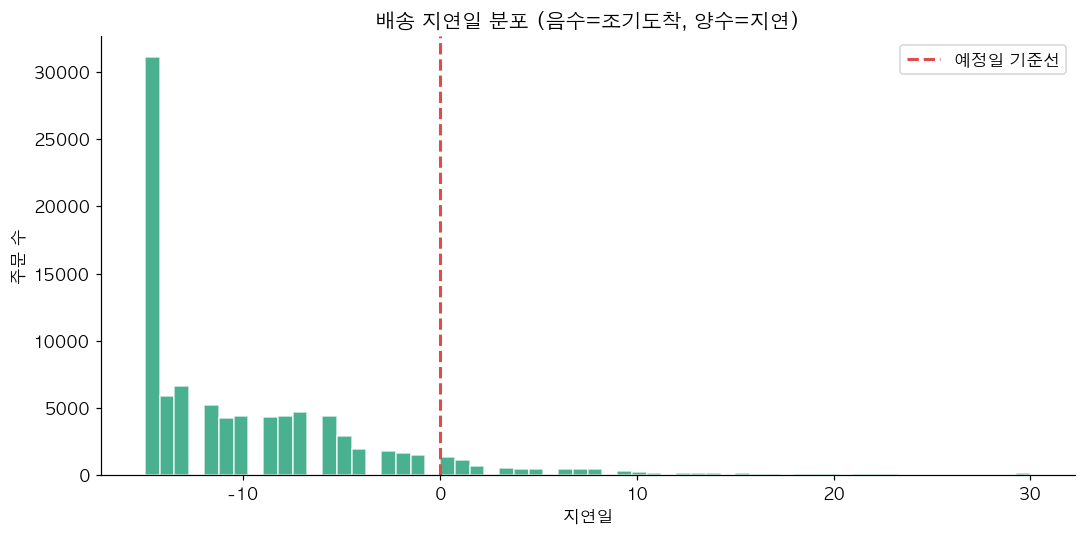

조기 도착: 91.0%
정시 도착: 1.4%
지연 도착: 7.5%


In [88]:
# ── 5-4: 라스트마일 소요일 분포 ──────────────────────────────────────────────

# 실제 소요일 vs 예상 소요일 분포 비교
plt.figure(figsize=(10, 5))
plt.hist(master['delivery_days_actual'].dropna(), bins=50, 
         color=C_BLUE, alpha=0.6, label='실제 배송 소요일')
plt.hist(master['delivery_days_estimated'].dropna(), bins=50, 
         color='orange', alpha=0.6, label='예상 배송 소요일')
plt.axvline(master['delivery_days_actual'].mean(), color=C_BLUE, 
            linestyle='--', label=f'실제 평균 {master["delivery_days_actual"].mean():.1f}일')
plt.axvline(master['delivery_days_estimated'].mean(), color='orange', 
            linestyle='--', label=f'예상 평균 {master["delivery_days_estimated"].mean():.1f}일')
plt.title('실제 배송 소요일 vs 예상 배송 소요일', fontweight='bold')
plt.xlabel('소요일')
plt.ylabel('주문 수')
plt.legend()
plt.tight_layout()
plt.show()

# 지연/정시/조기 도착 분포
delay_clipped = master['delivery_delay_days'].dropna().clip(-15, 30)

plt.figure(figsize=(10, 5))
plt.hist(delay_clipped, bins=60, color=C_OK, alpha=0.8, edgecolor='white')
plt.axvline(0, color=C_LATE, linestyle='--', linewidth=2, label='예정일 기준선')
plt.title('배송 지연일 분포 (음수=조기도착, 양수=지연)', fontweight='bold')
plt.xlabel('지연일')
plt.ylabel('주문 수')
plt.legend()
plt.tight_layout()
plt.show()

early = (master['delivery_delay_days'] < 0).sum()
ontime = (master['delivery_delay_days'] == 0).sum()
late = (master['delivery_delay_days'] > 0).sum()
total = len(master)
print(f'조기 도착: {early/total*100:.1f}%')
print(f'정시 도착: {ontime/total*100:.1f}%')
print(f'지연 도착: {late/total*100:.1f}%')

In [ ]:

# 라스트마일 소요일 히스토그램
plt.figure(figsize=(10, 5))
plt.hist(master['last_mile_days'].dropna(), bins=50, color=C_BLUE, alpha=0.8, edgecolor='white')
plt.axvline(mean_lm, color='red', linestyle='--', label=f'평균 {mean_lm:.1f}일')
plt.title('라스트마일 소요일 분포', fontweight='bold')
plt.xlabel('소요일')
plt.legend()
plt.tight_layout()
plt.show()

# 라스트마일 구간별 주문 수
plt.figure(figsize=(10, 5))
plt.bar(bucket_counts.index, bucket_counts.values, color=C_BLUE, alpha=0.8)
plt.title('라스트마일 구간별 주문 수', fontweight='bold')
plt.xlabel('구간')
plt.ylabel('주문 수')
plt.tight_layout()
plt.show()

late_rate = master['is_late'].mean()
print(f'전체 지연 배송률: {late_rate*100:.1f}%')
print(f'라스트마일 평균 소요일: {mean_lm:.1f}일')



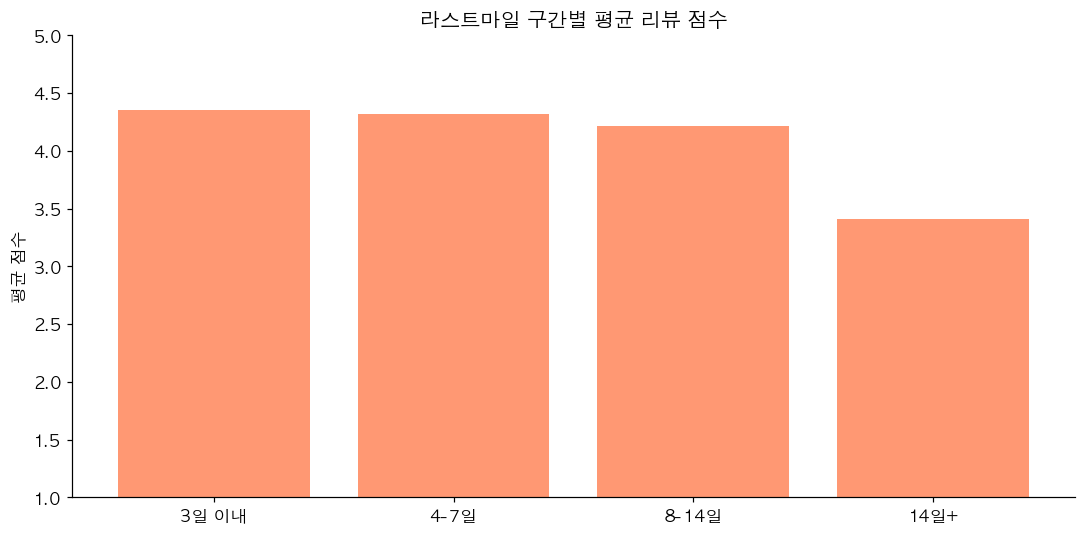

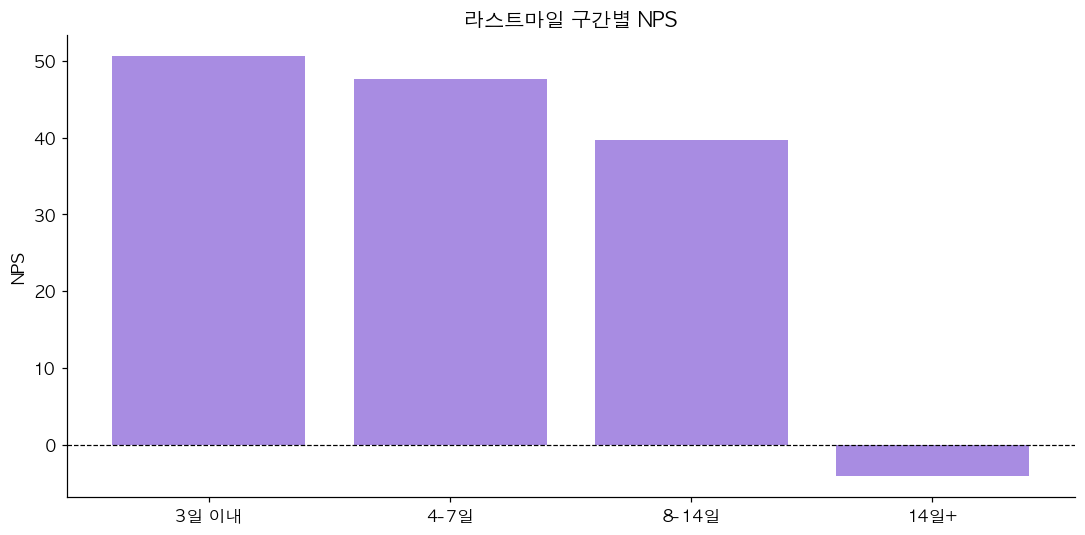

In [84]:
# ── 5-5: 라스트마일 × 만족도 ─────────────────────────────────────────────────
def calc_nps(df):
    total     = df['review_score'].notna().sum()
    promoter  = (df['review_score'] == 5).sum()
    detractor = (df['review_score'] <= 3).sum()
    return (promoter - detractor) / total * 100

score_by_bucket = master.groupby('last_mile_bucket')['review_score'].mean()
plt.figure(figsize=(10, 5))
plt.bar(score_by_bucket.index, score_by_bucket.values, color='coral', alpha=0.8)
plt.ylim(1, 5)
plt.title('라스트마일 구간별 평균 리뷰 점수', fontweight='bold')
plt.ylabel('평균 점수')
plt.tight_layout()
plt.show()

nps_by_bucket = master.groupby('last_mile_bucket').apply(calc_nps)
plt.figure(figsize=(10, 5))
plt.bar(nps_by_bucket.index, nps_by_bucket.values, color='mediumpurple', alpha=0.8)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('라스트마일 구간별 NPS', fontweight='bold')
plt.ylabel('NPS')
plt.tight_layout()
plt.show()

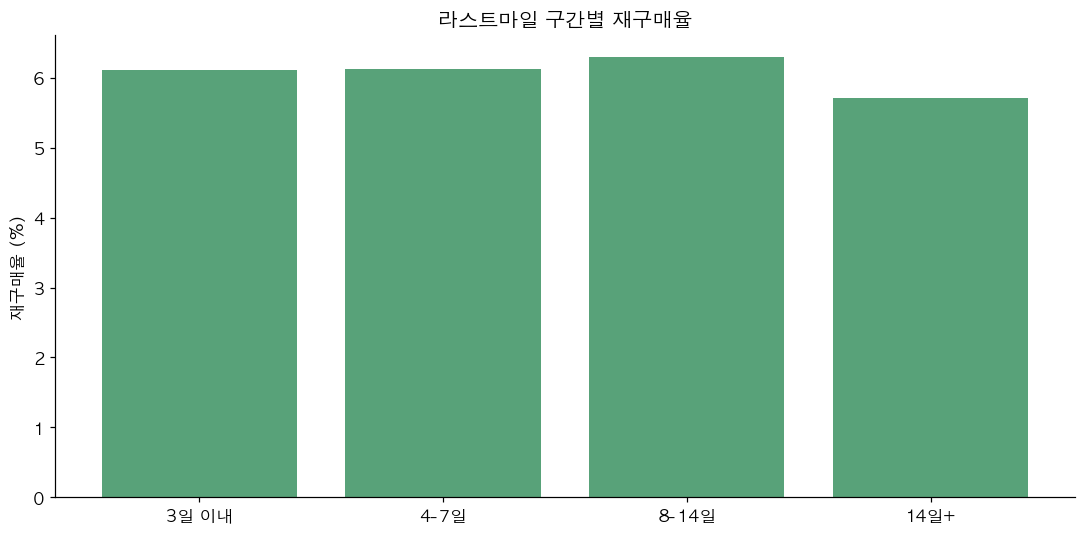

In [85]:
# ── 5-6: 라스트마일 × 재구매율 ───────────────────────────────────────────────
repurchase_by_bucket = master.groupby('last_mile_bucket')['is_repeat_customer'].mean() * 100

plt.figure(figsize=(10, 5))
plt.bar(repurchase_by_bucket.index, repurchase_by_bucket.values, color='seagreen', alpha=0.8)
plt.title('라스트마일 구간별 재구매율', fontweight='bold')
plt.ylabel('재구매율 (%)')
plt.tight_layout()
plt.show()

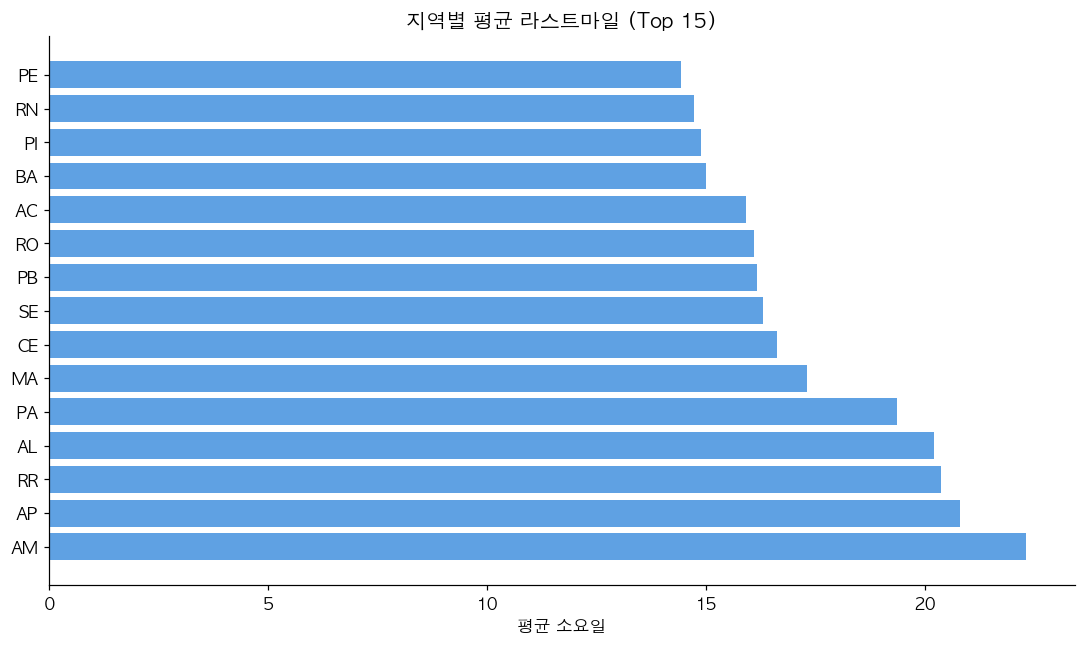

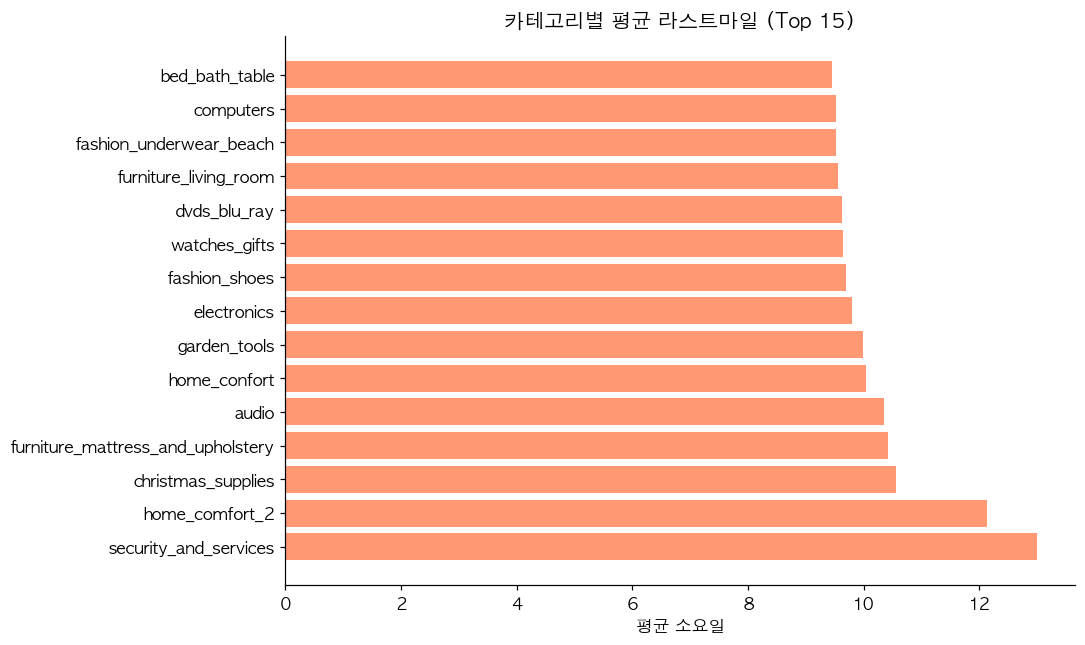

In [86]:
# ── 5-7: 지역 / 카테고리별 라스트마일 ────────────────────────────────────────
state_lm = master.groupby('customer_state')['last_mile_days'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
plt.barh(state_lm.index, state_lm.values, color=C_BLUE, alpha=0.8)
plt.title('지역별 평균 라스트마일 (Top 15)', fontweight='bold')
plt.xlabel('평균 소요일')
plt.tight_layout()
plt.show()

# 카테고리별 평균 라스트마일
cat_lm = master.groupby('category_en')['last_mile_days'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
plt.barh(cat_lm.index, cat_lm.values, color='coral', alpha=0.8)
plt.title('카테고리별 평균 라스트마일 (Top 15)', fontweight='bold')
plt.xlabel('평균 소요일')
plt.tight_layout()
plt.show()


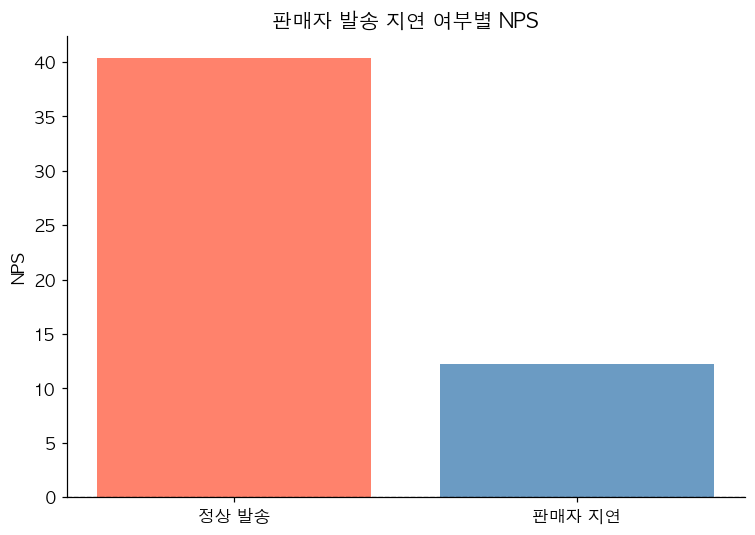

In [78]:
# ── 6-8: 판매자 지연 vs 물류 지연 ────────────────────────────────────────────
seller_nps = master.groupby('is_seller_late').apply(calc_nps).reset_index()
seller_nps.columns = ['is_seller_late', 'NPS']
seller_nps['label'] = seller_nps['is_seller_late'].map({True: '판매자 지연', False: '정상 발송'})

plt.figure(figsize=(7, 5))
plt.bar(seller_nps['label'], seller_nps['NPS'], color=['tomato', 'steelblue'], alpha=0.8)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('판매자 발송 지연 여부별 NPS', fontweight='bold')
plt.ylabel('NPS')
plt.tight_layout()
plt.show()

---
## STEP 6 · AARRR 분석 선정 근거

5단계 AARRR 중 **이 데이터로 가장 깊이 파고들 수 있는 2개**를 선정합니다.

| 단계 | 선정 | 이유 |
|------|------|------|
| Acquisition (유입) | ❌ | 마케팅 채널 데이터 없음 |
| Activation (첫 경험) | ❌ | 첫 구매 완료율 96.6% — 병목 아님 |
| Retention (재구매) | ❌ | 재구매율 3% 수준 — 데이터 불충분 |
| **Referral (추천)** | ✅ | NPS로 추천 의향 측정 가능, 배송 지연 시 디트랙터 4배 급증 |
| Revenue (매출/LTV) | ❌ | 채널/전환 데이터 없어 직접 측정 불가 |


> **핵심 가설**: 라스트마일 지연 → NPS 붕괴 → 디트랙터 증가 → 부정적 구전 → 서비스 성장 저해



In [109]:
print('=== 온타임 vs 지연: 평균 리뷰 점수 비교 ===')
comp = master.groupby('is_late')['review_score'].agg(['mean', 'count'])
comp.index = ['온타임', '지연']
comp.columns = ['평균 리뷰', '주문 수']
print(comp)

diff = comp.loc['온타임', '평균 리뷰'] - comp.loc['지연', '평균 리뷰']
print(f'\n→ 지연 배송 시 만족도 {diff:.2f}점 하락 → 가설 지지')

print('\n=== 라스트마일 구간별 평균 리뷰 점수 ===')
bucket_score = master.groupby('last_mile_bucket', observed=True)['review_score'].agg(['mean', 'count'])
bucket_score.columns = ['평균 리뷰', '주문 수']
print(bucket_score)
print('\n→ 라스트마일이 길수록 만족도 단계적 하락 → 가설 강화')


=== 온타임 vs 지연: 평균 리뷰 점수 비교 ===
     평균 리뷰   주문 수
온타임   4.29  86020
지연    2.46   6895

→ 지연 배송 시 만족도 1.83점 하락 → 가설 지지

=== 라스트마일 구간별 평균 리뷰 점수 ===
                  평균 리뷰   주문 수
last_mile_bucket              
3일 이내              4.36  20127
4-7일               4.32  31843
8-14일              4.22  26295
14일+               3.41  14650

→ 라스트마일이 길수록 만족도 단계적 하락 → 가설 강화


---
## STEP 7 - 라스트마일 배송 분석

**어디서, 어느 카테고리에서** 지연이 많이 발생하는지 파악합니다.

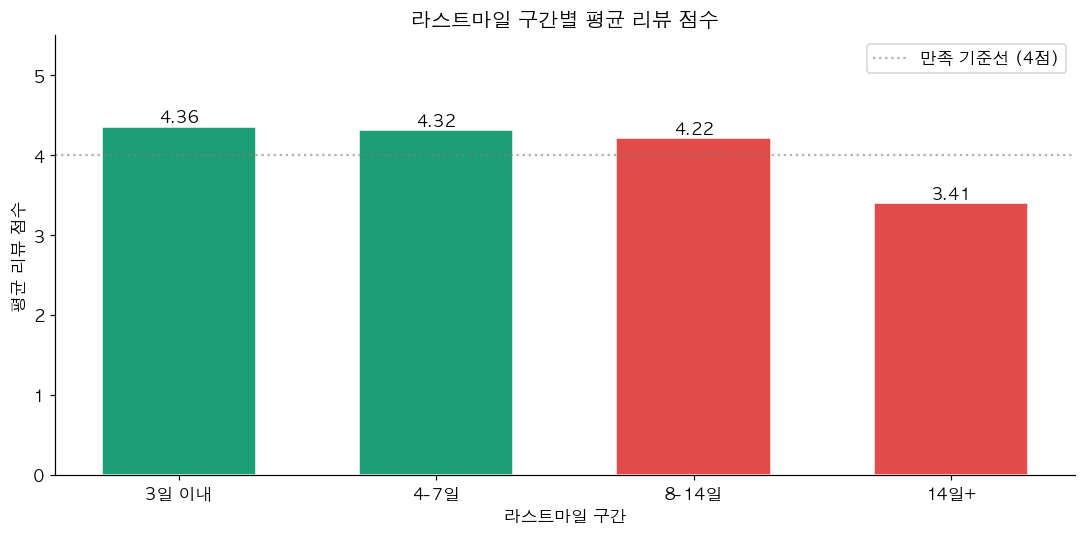

In [ ]:
# ── 7-1: 라스트마일 구간별 평균 리뷰 점수 ────────────────────────────────────
delay_review = (
    master.groupby('last_mile_bucket', observed=True)['review_score']
    .agg(['mean', 'count'])
    .reset_index()
)
delay_review.columns = ['구간', '평균 리뷰', '주문 수']

fig, ax = plt.subplots(figsize=(10, 5))
colors = [C_OK, C_OK, C_LATE, C_LATE]
bars = ax.bar(delay_review['구간'], delay_review['평균 리뷰'],
              color=colors, width=0.6, edgecolor='white')
for bar, val in zip(bars, delay_review['평균 리뷰']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, 5.5)
ax.axhline(4.0, color='gray', linestyle=':', alpha=0.6, label='만족 기준선 (4점)')
ax.set_title('라스트마일 구간별 평균 리뷰 점수', fontweight='bold')
ax.set_xlabel('라스트마일 구간')
ax.set_ylabel('평균 리뷰 점수')
ax.legend()
plt.tight_layout()
plt.show()

주(State)별 배송 성과 TOP 10:
customer_state   주문수  지연률_pct  평균리뷰  평균배송일
            SP 38045     5.49  4.24   8.50
            RJ 12179    12.46  3.97  14.53
            MG 11274     5.21  4.19  11.54
            RS  5307     6.52  4.19  14.77
            PR  4874     4.47  4.24  11.51
            SC  3525     9.11  4.13  14.45
            BA  3227    12.55  3.94  18.27
            DF  2067     6.63  4.14  12.57
            ES  1986    11.48  4.08  14.92
            GO  1947     7.34  4.11  14.99


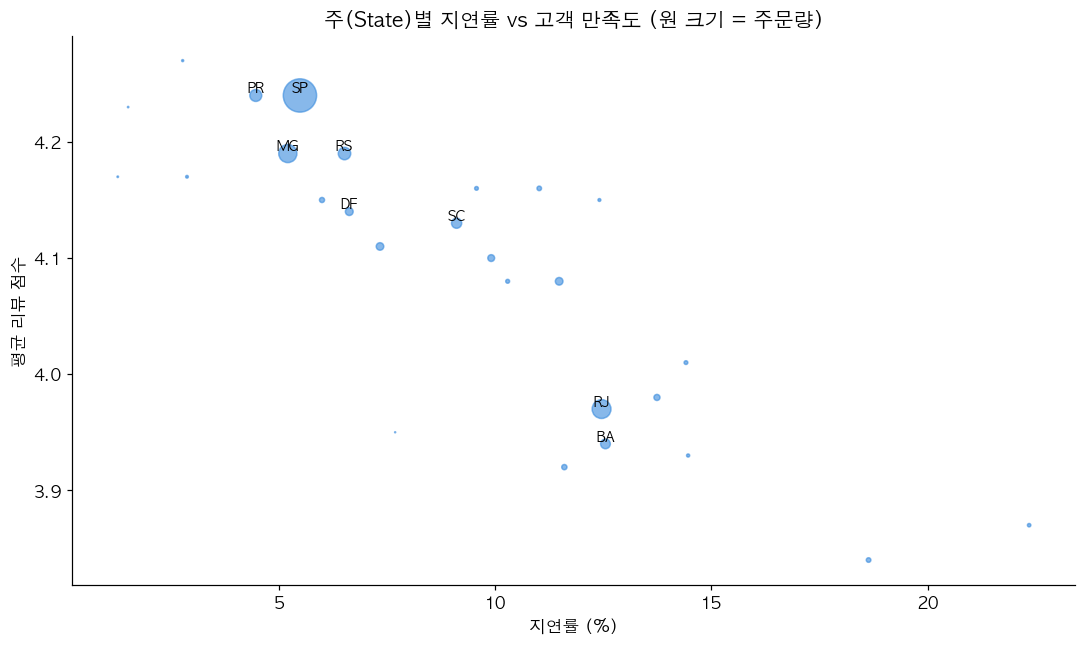

In [92]:
# ── 7-2: 주(State)별 지연률 & 만족도 ────────────────────────────────────────
state_perf = (
    master.groupby('customer_state')
    .agg(
        주문수     = ('order_id', 'count'),
        지연률_pct = ('is_late', lambda x: x.mean() * 100),
        평균리뷰   = ('review_score', 'mean'),
        평균배송일  = ('delivery_days_actual', 'mean'),
    )
    .round(2)
    .reset_index()
    .sort_values('주문수', ascending=False)
)

print('주(State)별 배송 성과 TOP 10:')
print(state_perf.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    state_perf['지연률_pct'],
    state_perf['평균리뷰'],
    s=state_perf['주문수'] / 80,
    alpha=0.6, color=C_BLUE
)
for _, row in state_perf.head(8).iterrows():
    ax.annotate(
        row['customer_state'],
        xy=(row['지연률_pct'], row['평균리뷰']),
        fontsize=9, ha='center', va='bottom'
    )
ax.set_xlabel('지연률 (%)')
ax.set_ylabel('평균 리뷰 점수')
ax.set_title('주(State)별 지연률 vs 고객 만족도 (원 크기 = 주문량)', fontweight='bold')
plt.tight_layout()
plt.show()

In [94]:
# 판매자 위치 분포 확인
print(sellers['seller_state'].value_counts().head(10))


seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
Name: count, dtype: int64


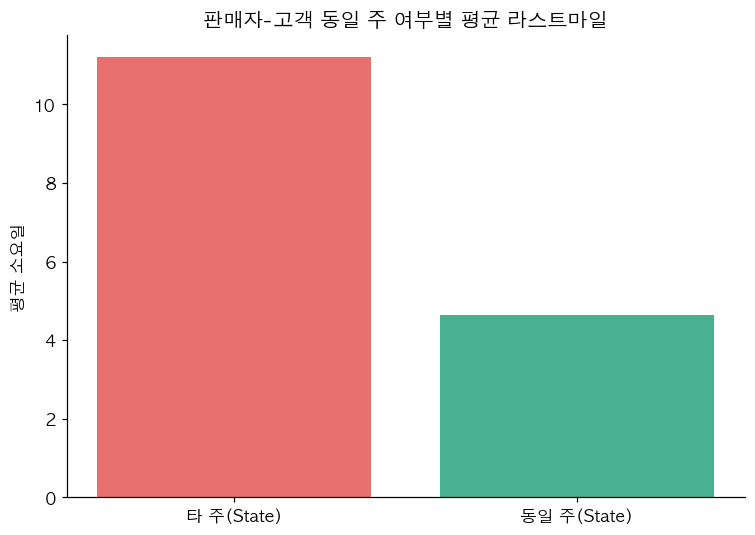

            last_mile_days  review_score
same_state                              
False                11.19          4.10
True                  4.63          4.25


In [97]:
# ── 7-2-1: 판매자-고객 주(State) 동일 여부 vs 라스트마일 ─────────────────────
master['same_state'] = master['customer_state'] == master['seller_state']

same_lm = master.groupby('same_state')['last_mile_days'].mean()
same_lm.index = ['타 주(State)', '동일 주(State)']

plt.figure(figsize=(7, 5))
plt.bar(same_lm.index, same_lm.values, color=[C_LATE, C_OK], alpha=0.8)
plt.title('판매자-고객 동일 주 여부별 평균 라스트마일', fontweight='bold')
plt.ylabel('평균 소요일')
plt.tight_layout()
plt.show()

print(master.groupby('same_state')[['last_mile_days', 'review_score']].mean().round(2))

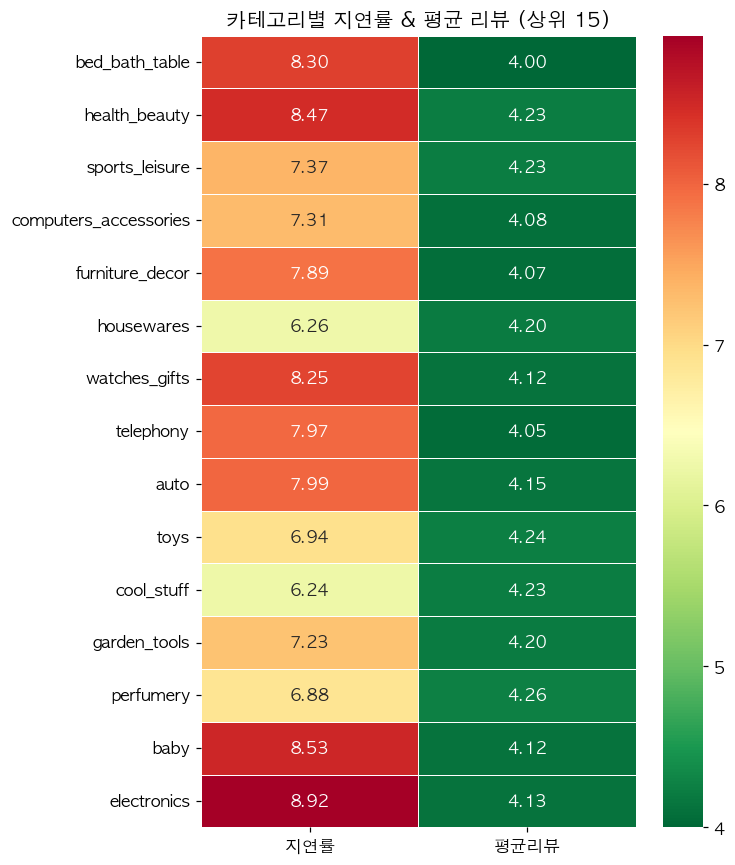

In [93]:
# ── 8-3: 카테고리별 배송 성과 ───────────────────────────────────────────────
cat_perf = (
    master.groupby('category_en')
    .agg(
        주문수    = ('order_id', 'count'),
        지연률    = ('is_late', lambda x: x.mean() * 100),
        평균리뷰  = ('review_score', 'mean'),
    )
    .round(2)
    .reset_index()
    .sort_values('주문수', ascending=False)
    .head(15)
)

hmap = cat_perf.set_index('category_en')[['지연률', '평균리뷰']]

fig, ax = plt.subplots(figsize=(7, 8))
sns.heatmap(hmap, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax)
ax.set_title('카테고리별 지연률 & 평균 리뷰 (상위 15)', fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

---
## STEP 9 · 고객 만족도 & NPS 분석

**NPS(Net Promoter Score)**: 고객 충성도를 측정하는 지표

```
NPS = (프로모터 비율 − 디트랙터 비율) × 100

  5점   → 프로모터   (적극 추천)
  4점 → 중립
  1-3점 → 디트랙터  (불만, 부정적 구전)
```

NPS는 -100 ~ +100 사이 값이며, +50 이상이면 우수한 편입니다.


In [98]:


# ── NPS 계산 함수 ────────────────────────────────────────────────────────────
def calc_nps(scores):
    """리뷰 점수 Series를 받아 NPS 관련 수치를 딕셔너리로 반환"""
    s = scores.dropna()
    promoters  = (s == 5).mean() * 100
    detractors = (s <= 3).mean() * 100
    neutrals   = 100 - promoters - detractors
    nps        = promoters - detractors
    return {
        '프로모터(%)': round(promoters, 1),
        '중립(%)':     round(neutrals, 1),
        '디트랙터(%)': round(detractors, 1),
        'NPS':         round(nps, 0),
        'n':           len(s),
    }

# 전체 / 온타임 / 지연 세 그룹 비교
groups = {
    '전체':   master['review_score'],
    '온타임':  master.loc[~master['is_late'], 'review_score'],
    '지연':    master.loc[ master['is_late'],  'review_score'],
}
nps_result = pd.DataFrame({k: calc_nps(v) for k, v in groups.items()}).T
print(nps_result)

     프로모터(%)  중립(%)  디트랙터(%)    NPS        n
전체     59.00  19.90    21.10  38.00 92915.00
온타임    62.10  20.50    17.30  45.00 86020.00
지연     20.10  11.60    68.30 -48.00  6895.00


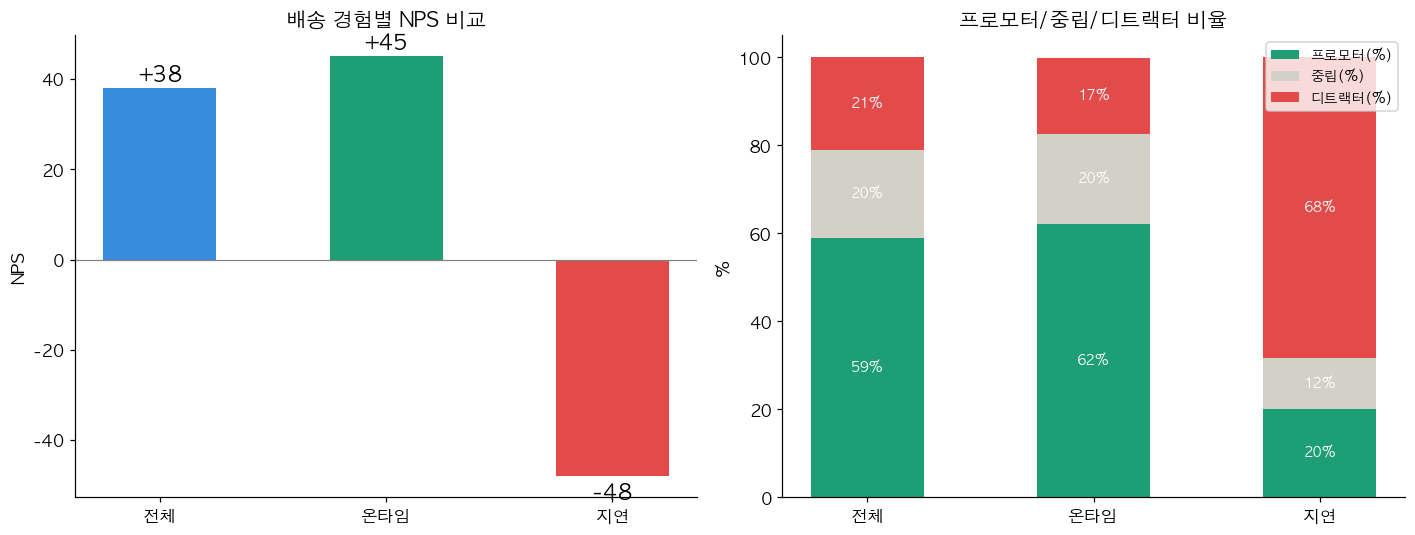

In [99]:
# ── NPS 시각화 ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 왼쪽: NPS 점수 막대 비교
nps_vals  = nps_result['NPS'].values
nps_names = nps_result.index.tolist()
nps_colors = [C_BLUE, C_OK, C_LATE]

bars = axes[0].bar(nps_names, nps_vals, color=nps_colors, width=0.5)
axes[0].axhline(0, color='gray', linewidth=0.8)
for bar, val in zip(bars, nps_vals):
    ypos = val + 1.5 if val >= 0 else val - 5
    axes[0].text(bar.get_x() + bar.get_width()/2, ypos,
                 f'{val:+.0f}', ha='center', fontsize=14, fontweight='bold')
axes[0].set_title('배송 경험별 NPS 비교', fontweight='bold')
axes[0].set_ylabel('NPS')

# 오른쪽: 온타임 vs 지연 — 점수 분포 Stacked Bar
pct_data = nps_result[['프로모터(%)', '중립(%)', '디트랙터(%)']]
colors_stack = [C_OK, '#D3D1C7', C_LATE]
bottom = np.zeros(len(pct_data))
for col, c in zip(pct_data.columns, colors_stack):
    axes[1].bar(pct_data.index, pct_data[col], bottom=bottom, color=c, label=col, width=0.5)
    for i, (val, bot) in enumerate(zip(pct_data[col], bottom)):
        if val > 5:
            axes[1].text(i, bot + val/2, f'{val:.0f}%',
                         ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    bottom += pct_data[col].values

axes[1].set_title('프로모터/중립/디트랙터 비율', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()


> **📌 핵심 인사이트**  
> - 온타임 NPS **+45** vs 지연 NPS **-48** → **93포인트 차이**  
> - 지연 시 디트랙터 **17% → 68%** (4배 급증)  
> - 지연 시 프로모터 **62% → 20%** (3분의 1 수준으로 붕괴)  
>
> 배송이 지연되는 순간 고객은 단순 불만족이 아닌 **적극적인 비추천자**로 전환된다.

---
## STEP 9 · Referral 심화 — 라스트마일 × NPS 상관관계

라스트마일 소요일이 NPS에 미치는 영향을 정량적으로 분석합니다.  
임계점(몇 일부터 NPS가 마이너스로 전환되는지)을 찾고,  
지역/카테고리별 NPS 취약 지점을 파악합니다.

라스트마일 소요일 vs 리뷰 점수 상관계수: -0.315


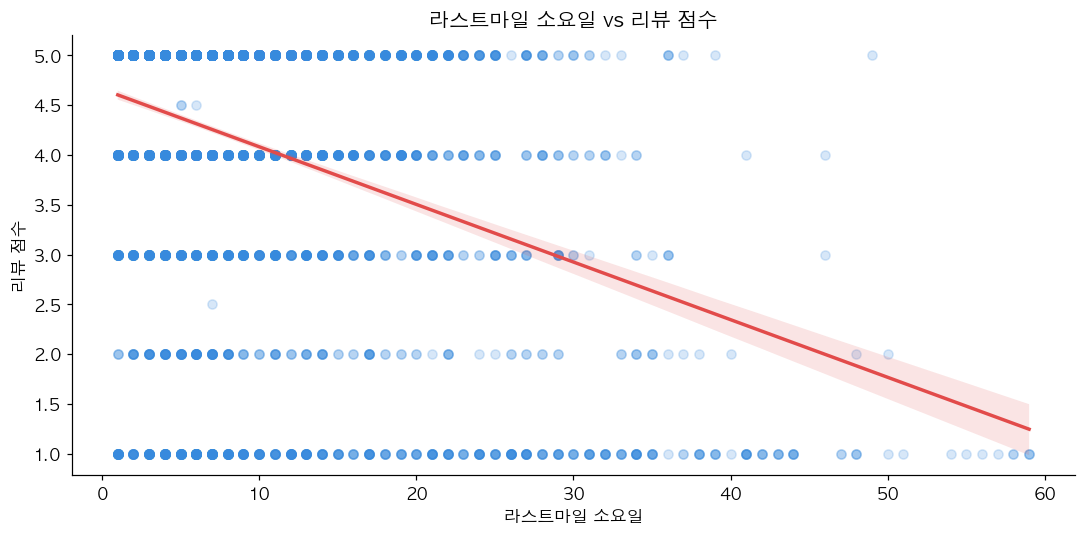

In [110]:
# ── 9-1: 라스트마일 소요일 vs 리뷰 점수 상관계수 ─────────────────────────────
corr = master[['last_mile_days', 'review_score']].corr().iloc[0, 1]
print(f'라스트마일 소요일 vs 리뷰 점수 상관계수: {corr:.3f}')

plt.figure(figsize=(10, 5))
sns.regplot(data=master.sample(5000, random_state=42),
            x='last_mile_days', y='review_score',
            scatter_kws={'alpha': 0.2, 'color': C_BLUE},
            line_kws={'color': C_LATE})
plt.title('라스트마일 소요일 vs 리뷰 점수', fontweight='bold')
plt.xlabel('라스트마일 소요일')
plt.ylabel('리뷰 점수')
plt.tight_layout()
plt.show()

  last_mile_bucket  프로모터(%)  디트랙터(%)   NPS
0            3일 이내    66.00    15.50 51.00
1             4-7일    64.10    16.50 48.00
2            8-14일    59.00    19.20 40.00
3             14일+    38.20    42.30 -4.00


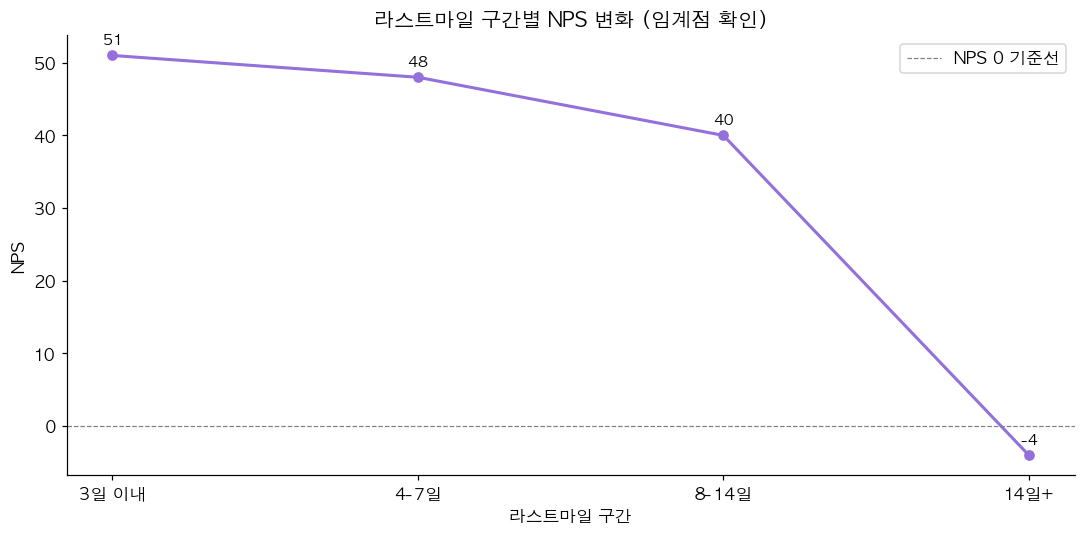

In [111]:
# ── 9-2: 구간별 NPS 변화 (임계점 찾기) ──────────────────────────────────────
nps_by_bucket = (
    master.groupby('last_mile_bucket', observed=True)
    .apply(lambda df: pd.Series(calc_nps(df['review_score'])))
    .reset_index()
)
print(nps_by_bucket[['last_mile_bucket', '프로모터(%)', '디트랙터(%)', 'NPS']])

plt.figure(figsize=(10, 5))
plt.plot(nps_by_bucket['last_mile_bucket'], nps_by_bucket['NPS'],
         marker='o', linewidth=2, color='mediumpurple')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8, label='NPS 0 기준선')
for _, row in nps_by_bucket.iterrows():
    plt.text(row['last_mile_bucket'], row['NPS'] + 1.5,
             f"{row['NPS']:.0f}", ha='center', fontsize=10, fontweight='bold')
plt.title('라스트마일 구간별 NPS 변화 (임계점 확인)', fontweight='bold')
plt.xlabel('라스트마일 구간')
plt.ylabel('NPS')
plt.legend()
plt.tight_layout()
plt.show()

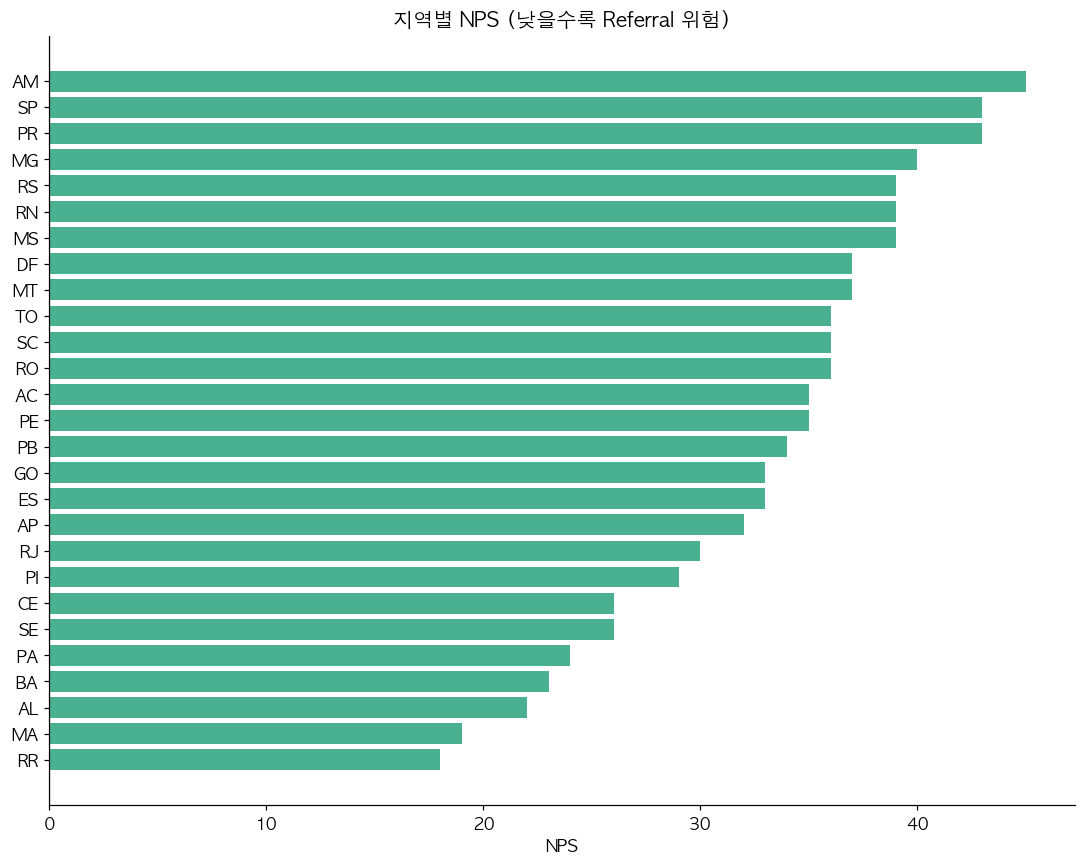

In [112]:
# ── 9-3: 지역별 NPS 취약 지점 ───────────────────────────────────────────────
state_nps = (
    master.groupby('customer_state')
    .apply(lambda df: pd.Series(calc_nps(df['review_score'])))
    .reset_index()
    .sort_values('NPS')
)

plt.figure(figsize=(10, 8))
colors = [C_LATE if x < 0 else C_OK for x in state_nps['NPS']]
plt.barh(state_nps['customer_state'], state_nps['NPS'], color=colors, alpha=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.title('지역별 NPS (낮을수록 Referral 위험)', fontweight='bold')
plt.xlabel('NPS')
plt.tight_layout()
plt.show()

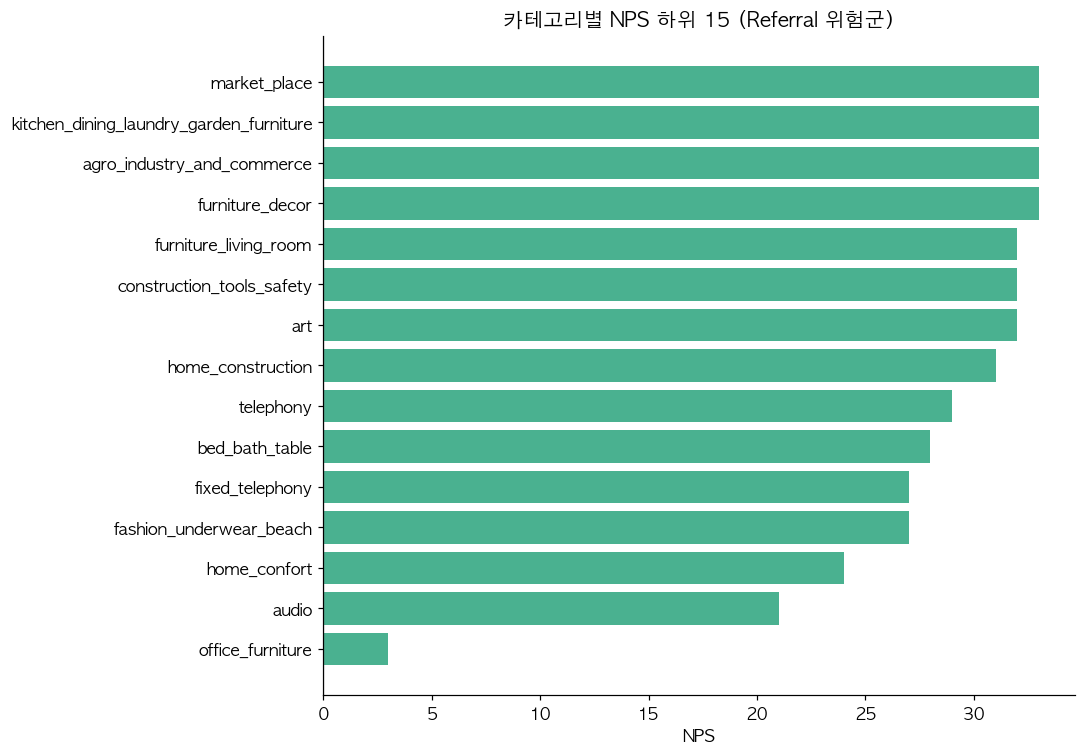

In [113]:
# ── 9-4: 카테고리별 NPS 취약 지점 ──────────────────────────────────────────
cat_nps = (
    master.groupby('category_en')
    .apply(lambda df: pd.Series(calc_nps(df['review_score'])))
    .reset_index()
)
cat_nps = cat_nps[cat_nps['n'] >= 100].sort_values('NPS').head(15)

plt.figure(figsize=(10, 7))
colors = [C_LATE if x < 0 else C_OK for x in cat_nps['NPS']]
plt.barh(cat_nps['category_en'], cat_nps['NPS'], color=colors, alpha=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.title('카테고리별 NPS 하위 15 (Referral 위험군)', fontweight='bold')
plt.xlabel('NPS')
plt.tight_layout()
plt.show()

---
## STEP 10 · 코호트 분석 — 월별 NPS & 라스트마일 추이

첫 구매 월 기준으로 NPS와 라스트마일 소요일이 시간에 따라 어떻게 변했는지 확인합니다.  
"배송 품질이 개선되고 있는가, 아니면 악화되고 있는가?" 

In [114]:
# ── 10-1: 월별 첫 구매 고객 NPS 추이 ─────────────────────────────────────────
# 고객별 첫 구매 월 추출
first_purchase = (
    master.groupby('customer_unique_id')['order_purchase_timestamp']
    .min()
    .dt.to_period('M')
    .reset_index()
    .rename(columns={'order_purchase_timestamp': 'cohort_month'})
)

master_cohort = master.merge(first_purchase, on='customer_unique_id', how='left')

# 코호트 월별 NPS 계산
cohort_nps = (
    master_cohort.groupby('cohort_month')
    .apply(lambda df: pd.Series(calc_nps(df['review_score'])))
    .reset_index()
)
cohort_nps['cohort_month'] = cohort_nps['cohort_month'].astype(str)

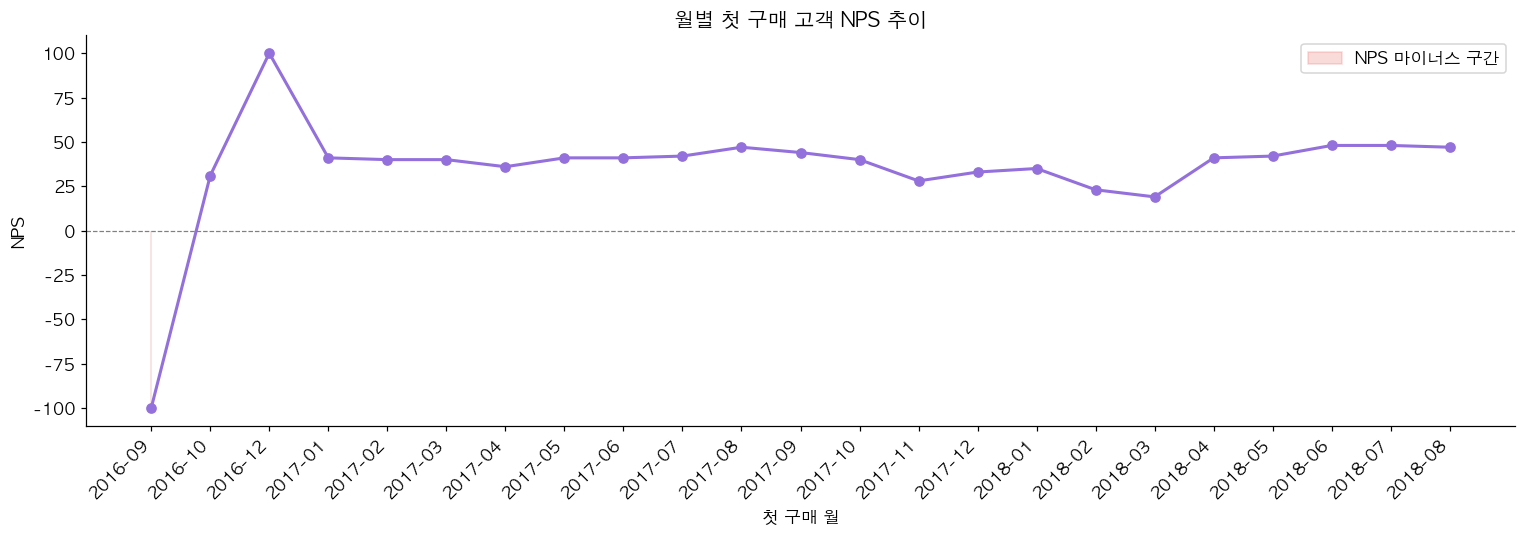

In [115]:
# ── 10-2: 코호트별 NPS 추이 시각화 ───────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(cohort_nps['cohort_month'], cohort_nps['NPS'],
         marker='o', linewidth=2, color='mediumpurple')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.fill_between(cohort_nps['cohort_month'], cohort_nps['NPS'],
                 where=cohort_nps['NPS'] < 0, color=C_LATE, alpha=0.2, label='NPS 마이너스 구간')
plt.xticks(rotation=45, ha='right')
plt.title('월별 첫 구매 고객 NPS 추이', fontweight='bold')
plt.xlabel('첫 구매 월')
plt.ylabel('NPS')
plt.legend()
plt.tight_layout()
plt.show()

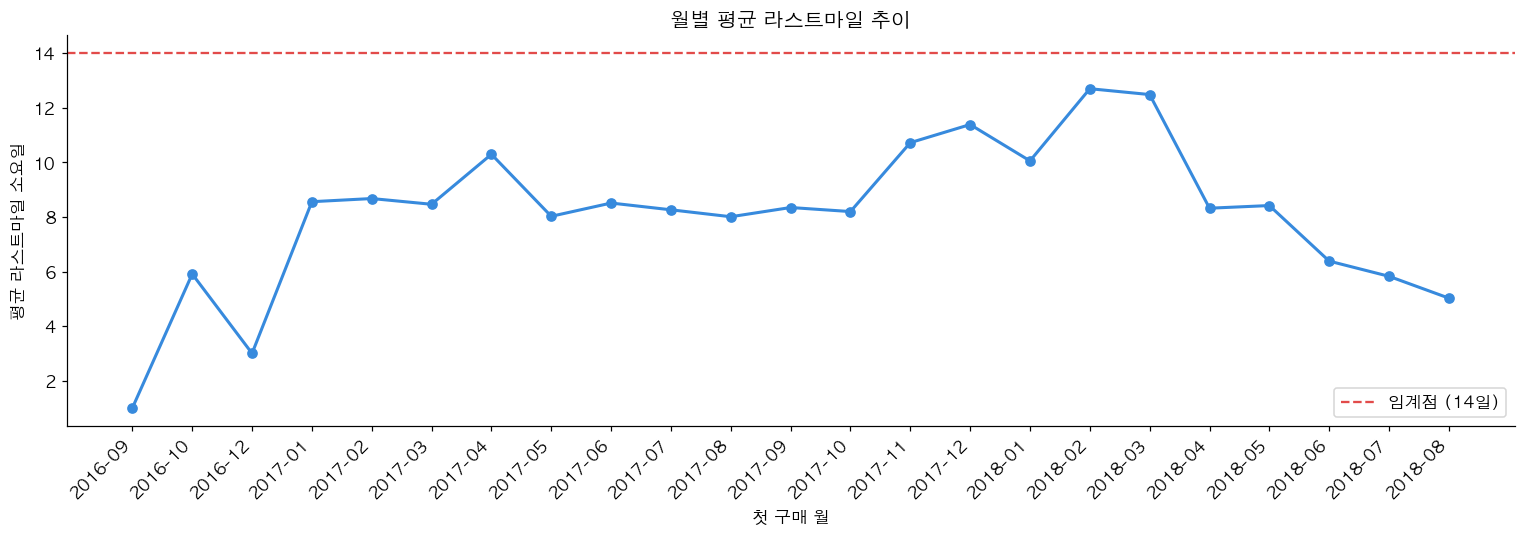

배송 품질이 개선되는 추세인가?
초기 (2017 상반기) 평균 라스트마일: 6.9일
후기 (2018 상반기) 평균 라스트마일: 8.5일


In [116]:
# ── 10-3: 코호트별 라스트마일 평균 추이 ──────────────────────────────────────
cohort_lm = (
    master_cohort.groupby('cohort_month')['last_mile_days']
    .mean()
    .reset_index()
)
cohort_lm['cohort_month'] = cohort_lm['cohort_month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(cohort_lm['cohort_month'], cohort_lm['last_mile_days'],
         marker='o', linewidth=2, color=C_BLUE)
plt.axhline(14, color=C_LATE, linestyle='--', linewidth=1.5, label='임계점 (14일)')
plt.xticks(rotation=45, ha='right')
plt.title('월별 평균 라스트마일 추이', fontweight='bold')
plt.xlabel('첫 구매 월')
plt.ylabel('평균 라스트마일 소요일')
plt.legend()
plt.tight_layout()
plt.show()

print('배송 품질이 개선되는 추세인가?')
print(f'초기 (2017 상반기) 평균 라스트마일: {cohort_lm[cohort_lm["cohort_month"] < "2017-07"]["last_mile_days"].mean():.1f}일')
print(f'후기 (2018 상반기) 평균 라스트마일: {cohort_lm[cohort_lm["cohort_month"] > "2018-01"]["last_mile_days"].mean():.1f}일')

> **📌 코호트 분석 인사이트**  
> - 2016-09 초기 데이터는 샘플 수 부족으로 NPS 튀는 현상 → 무시  
> - 전반적으로 NPS **+20 ~ +50** 사이 안정적 유지  
> - 2017-11 ~ 2018-03 라스트마일 **10~12일대 급등** 구간에서 NPS 동반 하락  
>
> **"주문량 급증 시기에 물류 인프라가 따라가지 못해 라스트마일이 악화되고 NPS가 하락하는 구조적 문제"**

---
## STEP 11 · 물류 공백 클러스터링 — 물류센터 위치 제안

라스트마일 소요일을 가중치로 반영한 K-Means 클러스터링으로  
물류센터 건설 우선순위 지역을 도출합니다.

In [120]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [117]:
# ── 12-1: 지연 집중 고객 위치 추출 ───────────────────────────────────────────
# geo 테이블 중복 제거 (우편번호별 대표 좌표)
geo_clean = (
    geo.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']]
    .mean()
    .reset_index()
)

# 고객 우편번호 → 위도/경도 매핑
customers_geo = customers.merge(
    geo_clean,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)

# master에 위도/경도 추가
master_geo = master.merge(
    customers_geo[['customer_id', 'geolocation_lat', 'geolocation_lng']],
    on='customer_id', how='left'
).dropna(subset=['geolocation_lat', 'geolocation_lng'])

print(f'위치 매핑 완료: {len(master_geo):,}행')

위치 매핑 완료: 93,279행


In [128]:
# master에 위도/경도 추가 후 dropna
master_geo = master.merge(
    customers_geo[['customer_id', 'geolocation_lat', 'geolocation_lng']],
    on='customer_id', how='left'
)

# 매핑 후 결측치 제거
print(f'매핑 전: {len(master_geo):,}행')
master_geo = master_geo.dropna(subset=['geolocation_lat', 'geolocation_lng'])
print(f'매핑 후: {len(master_geo):,}행')


매핑 전: 93,537행
매핑 후: 93,279행


In [132]:
# ── 12-2: 라스트마일 14일+ 초과 고객만 추출 ──────────────────────────────────
high_delay = master_geo[master_geo['last_mile_days'] >= 14].copy()
print(f'14일+ 지연 고객: {len(high_delay):,}건 ({len(high_delay)/len(master_geo)*100:.1f}%)')


14일+ 지연 고객: 17,564건 (18.8%)


In [134]:
# ── 12-3: 가중치 K-Means 클러스터링 (라스트마일 소요일 가중치 반영) ────────────
# 전체 master_geo 사용, 라스트마일 소요일 가중치
coords_all = master_geo[['geolocation_lat', 'geolocation_lng']].copy()
weight = (master_geo['last_mile_days'] / master_geo['last_mile_days'].mean()).astype(int).clip(lower=1)

coords_rep2 = coords_all.loc[
    coords_all.index.repeat(weight)
][['geolocation_lat', 'geolocation_lng']]

kmeans3 = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans3.fit(coords_rep2)
centers = kmeans3.cluster_centers_

master_geo['cluster'] = kmeans3.predict(
    master_geo[['geolocation_lat', 'geolocation_lng']]
)

print('물류센터 후보 위치 (전체 데이터 + 라스트마일 가중치):')
for i, (lat, lng) in enumerate(centers):
    mask = master_geo['cluster'] == i
    print(f'  후보 {i+1}: ({lat:.2f}, {lng:.2f})  커버: {mask.sum():,}건  평균 라스트마일: {master_geo[mask]["last_mile_days"].mean():.1f}일')


물류센터 후보 위치 (전체 데이터 + 라스트마일 가중치):
  후보 1: (-9.14, -38.12)  커버: 8,232건  평균 라스트마일: 15.5일
  후보 2: (-22.54, -45.22)  커버: 58,708건  평균 라스트마일: 7.2일
  후보 3: (-27.40, -50.94)  커버: 13,989건  평균 라스트마일: 10.2일
  후보 4: (-4.06, -51.09)  커버: 2,442건  평균 라스트마일: 18.0일
  후보 5: (-18.07, -49.89)  커버: 9,908건  평균 라스트마일: 9.5일


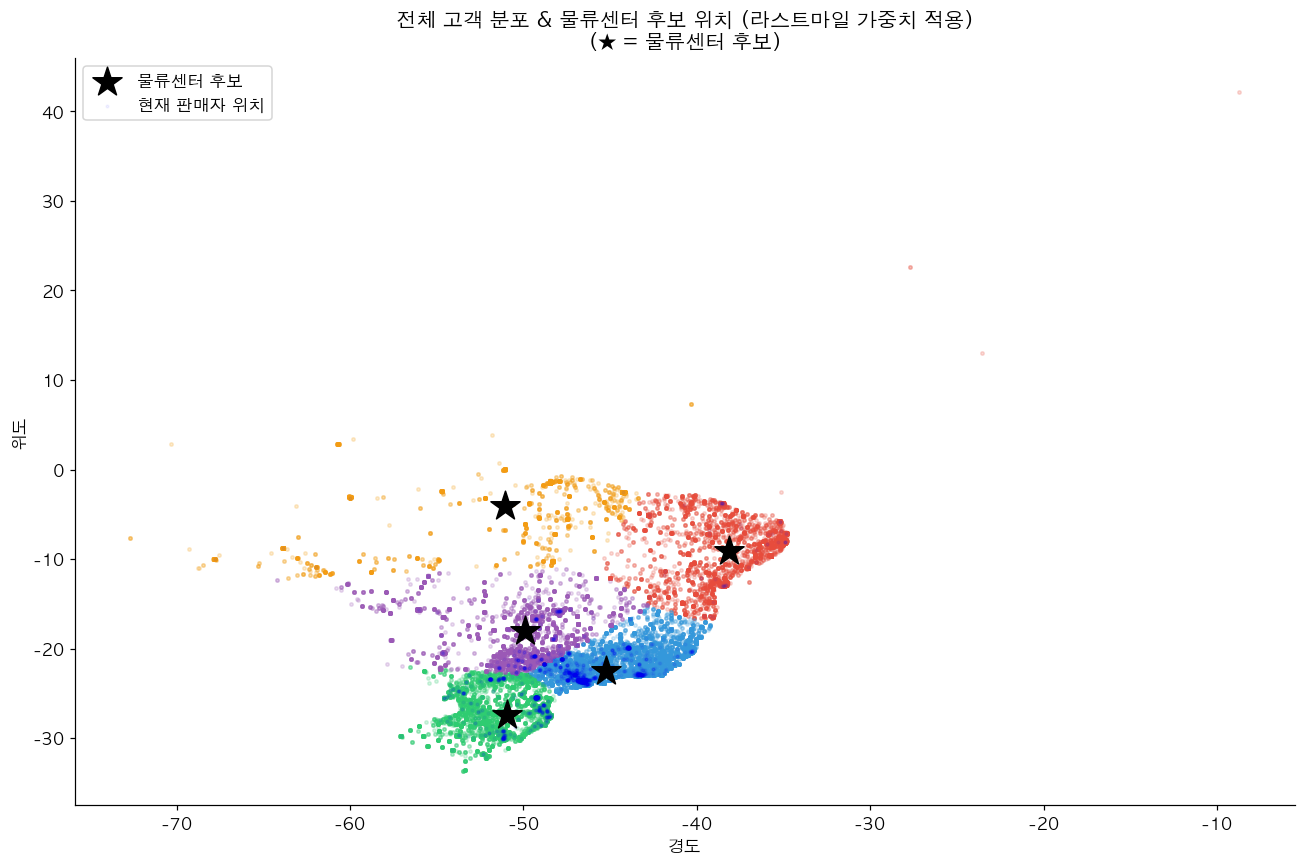

In [137]:
# ── 12-4: 시각화 ─────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 8))

# 지연 고객 산점도
scatter_colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
for i in range(5):
    cluster_data = master_geo[master_geo['cluster'] == i]
    plt.scatter(cluster_data['geolocation_lng'],
                cluster_data['geolocation_lat'],
                c=scatter_colors[i], alpha=0.2, s=5)

# 물류센터 후보 위치
plt.scatter(centers[:, 1], centers[:, 0],
            c='black', marker='*', s=400, zorder=5, label='물류센터 후보')

# 현재 판매자 위치 (SP 집중)
sellers_geo = sellers.merge(
    geo_clean,
    left_on='seller_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
).dropna()
plt.scatter(sellers_geo['geolocation_lng'], sellers_geo['geolocation_lat'],
            c='blue', alpha=0.05, s=3, label='현재 판매자 위치')

plt.title('전체 고객 분포 & 물류센터 후보 위치 (라스트마일 가중치 적용)\n(★ = 물류센터 후보)', fontweight='bold')
plt.xlabel('경도')
plt.ylabel('위도')
plt.legend()
plt.tight_layout()
plt.show()

---
## STEP 12 · 인사이트 & 액션 플랜

분석을 통해 도출된 핵심 수치를 정리하고, 구체적인 액션 플랜을 제시합니다.

In [138]:

# ── 13-1: 핵심 수치 요약 ─────────────────────────────────────────────────────
print('=' * 55)
print('핵심 분석 결과 요약')
print('=' * 55)

ontime_nps = calc_nps(master[~master['is_late']]['review_score'])['NPS']
late_nps   = calc_nps(master[master['is_late']]['review_score'])['NPS']
ontime_det = calc_nps(master[~master['is_late']]['review_score'])['디트랙터(%)']
late_det   = calc_nps(master[master['is_late']]['review_score'])['디트랙터(%)']

print(f'\n[라스트마일 임계점]')
print(f'  14일 초과 시 NPS 마이너스로 전환')

print(f'\n[NPS 차이]')
print(f'  온타임 NPS : {ontime_nps:+.0f}')
print(f'  지연 NPS   : {late_nps:+.0f}')
print(f'  차이        : {ontime_nps - late_nps:.0f}포인트')

print(f'\n[디트랙터 변화]')
print(f'  온타임 디트랙터: {ontime_det:.1f}%')
print(f'  지연 디트랙터  : {late_det:.1f}%  ({late_det/ontime_det:.1f}배 증가)')

print(f'\n[코호트]')
print(f'  주문량 급증 시기(2017 하반기) 라스트마일 악화')
print(f'  → 성장이 물류 인프라를 앞지르는 구조적 문제')

print(f'\n[물류 공백 지역]')
print(f'  후보 4 북부 (PA)    평균 라스트마일 18.0일 ← 1순위')
print(f'  후보 1 동북부 (BA)  평균 라스트마일 15.5일 ← 2순위')

핵심 분석 결과 요약

[라스트마일 임계점]
  14일 초과 시 NPS 마이너스로 전환

[NPS 차이]
  온타임 NPS : +45
  지연 NPS   : -48
  차이        : 93포인트

[디트랙터 변화]
  온타임 디트랙터: 17.3%
  지연 디트랙터  : 68.3%  (3.9배 증가)

[코호트]
  주문량 급증 시기(2017 하반기) 라스트마일 악화
  → 성장이 물류 인프라를 앞지르는 구조적 문제

[물류 공백 지역]
  후보 4 북부 (PA)    평균 라스트마일 18.0일 ← 1순위
  후보 1 동북부 (BA)  평균 라스트마일 15.5일 ← 2순위


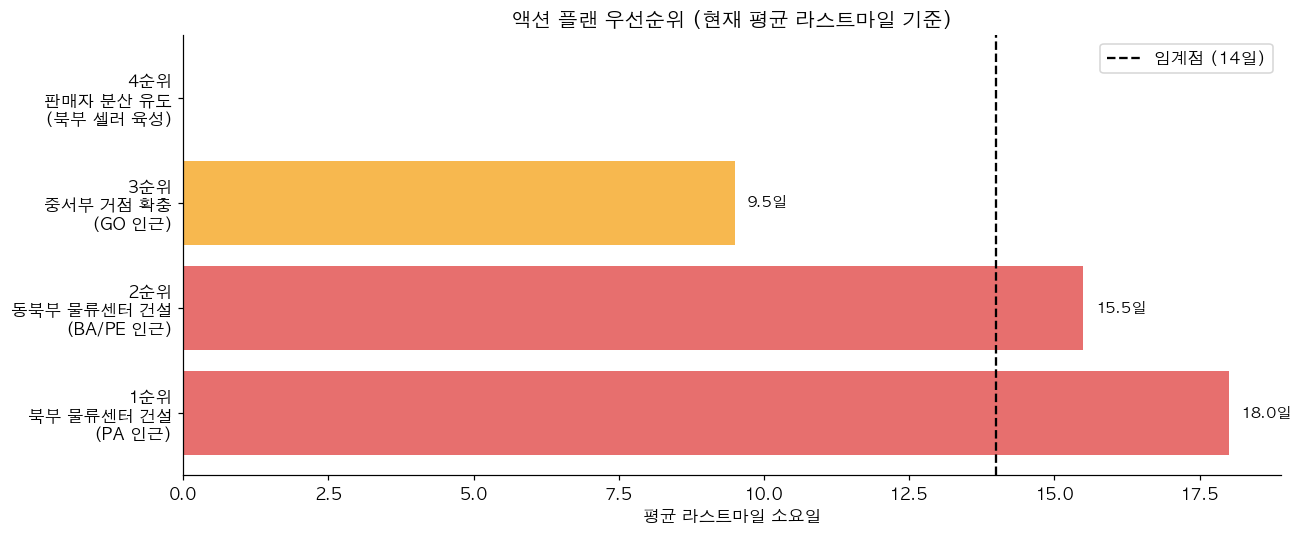

In [139]:
# ── 13-2: 액션 플랜 시각화 ───────────────────────────────────────────────────
actions = {
    '1순위\n북부 물류센터 건설\n(PA 인근)':       18.0,
    '2순위\n동북부 물류센터 건설\n(BA/PE 인근)':  15.5,
    '3순위\n중서부 거점 확충\n(GO 인근)':          9.5,
    '4순위\n판매자 분산 유도\n(북부 셀러 육성)':   0,
}

fig, ax = plt.subplots(figsize=(12, 5))
colors = [C_LATE, C_LATE, '#F5A623', C_OK]
bars = ax.barh(list(actions.keys()), list(actions.values()),
               color=colors, alpha=0.8)
ax.axvline(14, color='black', linestyle='--', linewidth=1.5, label='임계점 (14일)')
for bar, val in zip(bars, actions.values()):
    if val > 0:
        ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
                f'{val}일', va='center', fontsize=10, fontweight='bold')
ax.set_title('액션 플랜 우선순위 (현재 평균 라스트마일 기준)', fontweight='bold')
ax.set_xlabel('평균 라스트마일 소요일')
ax.legend()
plt.tight_layout()
plt.show()

In [140]:

# ── 13-3: 기대 효과 ──────────────────────────────────────────────────────────
print('\n[기대 효과]')
print('  북부/동북부 물류센터 건설 시')
print('  → 라스트마일 14일 이내로 단축')
print('  → NPS 마이너스 → 플러스 전환')
print('  → 디트랙터 감소 → 부정적 구전 차단')
print('  → Referral 회복 → 서비스 성장 지속 가능')



[기대 효과]
  북부/동북부 물류센터 건설 시
  → 라스트마일 14일 이내로 단축
  → NPS 마이너스 → 플러스 전환
  → 디트랙터 감소 → 부정적 구전 차단
  → Referral 회복 → 서비스 성장 지속 가능
